In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline
%pip install graphviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

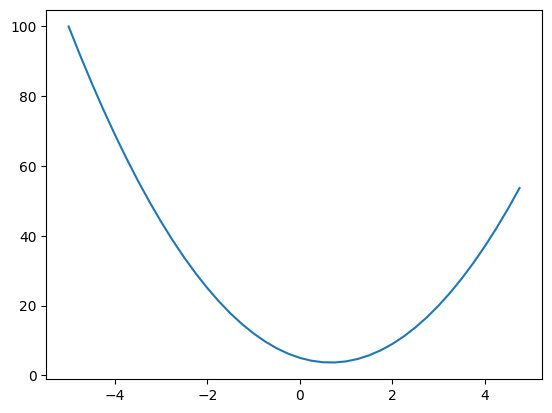

In [4]:
xs = np.arange(-5, 5, 0.25)
xs
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.00000001
x = 2/3
(f(x+h) - f(x))/h

0.0

In [6]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("Slope", (d2-d1)/h)

d1 4.0
d2 4.000000099999999
Slope 0.999999993922529


In [2]:
#Here we are defining each node and its value, we are also defining operations with the nodes

from typing import Any


class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None #value used to automate backpropagation
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #if other is not an instance, we assume it is an int or a float (we do this in order to be able to pass integers/floats)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad # derivative of itself * grad of the output
            other.grad += 1.0 * out.grad
        out._backward = _backward # addition propagates grad

        return out

    def __neg__(self): # negate a value
        return self * -1

    def __sub__(self, other):
        return self + (-other)
        

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad # value of the other multiplying value * output grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)) # ensure the power is an int or a float
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other-1) * out.grad #d(out)/dx * dL/d(out) = dL/dx
        out._backward = _backward

        return out


    def __rmul__(self, other): #fallback if mul fails
        return self * other


    def __truediv__(self, other): #self / other
        return self*other**-1


    def tanh(self):
        x = self.data
        t = ((math.exp(2*x) - 1)/(math.exp(2*x) + 1))
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad # t in here represents tan(x), and the entire expression represents the derivative 1-tan(x)^2 * out.grad
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad #since we use the exponent in out, we define it as the exponent * the grad of the output (dout/dx = e**x) -> 1*e**x
        out._backward = _backward

        return out

    def backward(self): #implementing backprop

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0); f.label='f'
L = d * f; L.label = 'L'
#(a.__mul__(b)).__add__(c)

In [3]:
a = Value(2.0)
a + 2

a = Value(3.0)
a * 3
3 * a
a = Value(3.0)
b = Value(2.0)
a / b
a-b
# a * (1/b)
# a * (b**-1)
# x**k

Value(data=1.0)

In [10]:
d._prev #This will give us the previous operations in the graph (a*b) and c

{Value(data=-6.0), Value(data=10.0)}

In [11]:
d._op

'+'

In [4]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | Grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

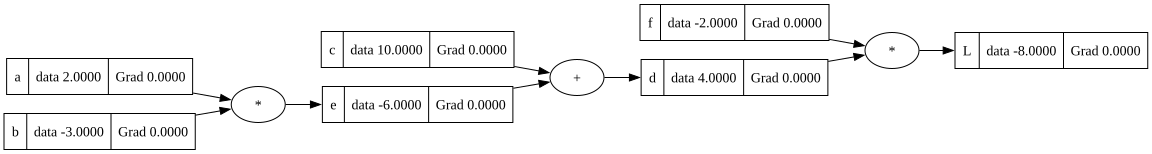

In [5]:
draw_dot(L) #Plotting all the layers of operations

In [14]:
a.data += 0.001*a.grad
b.data += 0.001*b.grad
c.data += 0.001*c.grad
f.data += 0.001*f.grad

#since we are moving in the positive direction of the gradient, we expect a greater value for the data of L.

e = a*b
d = e+c
L = d * f

print(L.data)


-32.0


In [15]:
L.grad = 1.0 #manually setting L to 1 to start the backprop

In [16]:
# L = d * f

# dL/df = d = -2.0
# dL/dd = f = 4.0

f.grad = 4.0
d.grad = -2.0

# L = (e+c)*f = (f*e) + (f*c)

#dL/de = f = -2
#dL/dc = f = -2

e.grad = -2.0
c.grad = -2.0


# L = (f*(a*b)) + (f*c) = fab + fc

#dL/da = f*b = -2*-3 = 6.0
#dL/db = f*a = -2*2 = -4.0

a.grad = 6.0
b.grad = -4.0


In [17]:
#grad, derivative of L with respect to a, b, c, d, e, f

def lol():

    h = 0.00001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0); f.label='f'
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0); f.label='f'
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

0.0


In [6]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

# x1*w1 + x1*w2 + b
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2' # we use a dot product so the NN can focus on relevant features
n = x1w1x2w2 + b; n.label = 'n'

# We apply an activation function because the real world is not linear, the activation function lets you model complex relationships
# Dot product: “Price = 0.5×size + 0.3×location + 0.2×age”. 
# Activation: “But prices don’t grow linearly -> apply a curve”

# ---
#o = n.tanh(); o.label='o' # include the activation function in the outputw
# ---

#defining the tanh function with exp and -
e = (2*n).exp()
o = (e-1)/(e+1)


o.backward()

In [13]:
# Same in pytorch

import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad=True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad=True
b = torch.Tensor([6.881373587019543]).double(); b.requires_grad=True
n_torch = x1*w1 + x2*w2 + b
o_torch = torch.tanh(n_torch)

print(o_torch.data.item())
o_torch.backward()

print("----")
print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [14]:
torch.tensor([[1, 2, 3],[4, 5, 6]])

tensor([[1, 2, 3],
        [4, 5, 6]])

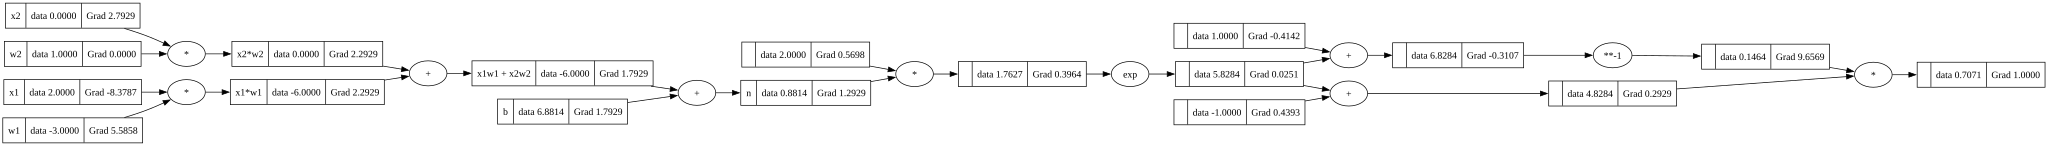

In [15]:
draw_dot(o)

In [22]:
o.backward()

In [23]:
o.grad = 1.0

In [24]:
n.grad = 0.5

In [25]:
# o = tanh(n)
# do/dn = 1-tanh(n)**2 = 1-o**2

1-o.data**2 # grad of n * o that is 1 (multiply because of the chain rule)

0.4999999999999998

In [7]:
# The + sign is a distribuitor of gradient

# do/dx1w1x2w2 = 0.5
# do/b = 0.5

b.grad = 0.5
x1w1x2w2.grad = 0.5

# do/dx1w1 = 0.5
# do/dx2w2 = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

# do/x1
# do/w1
# do/x2
# do/w2

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad # since we are multiplying by 0 (x2), w2 gradient never changes because it doesnt affect to o.

In [ ]:
# Implementing backprop automatically,
o.grad = 1.0
o._backward() # o is the output of tanh, so it will call the tanh function
   
n._backward() # addition backprop
x1w1x2w2._backward() # addition backprop (others data * output grad)
   
x1w1._backward() # mult backprop (1.0 * output grad)
x2w2._backward() # mult backprop
   
o.backward() # walks the graph in topological order and runs all local _backward() steps


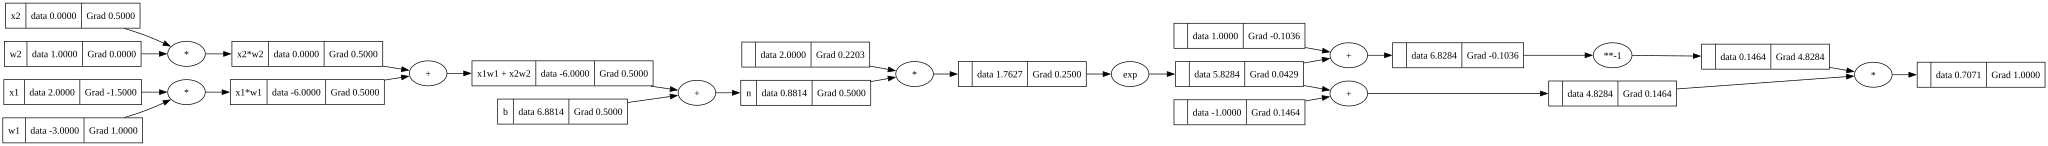

In [8]:
draw_dot(o)

In [9]:
o.backward()

In [16]:
# Building topological graph

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data=2),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=1.7627471740390863),
 Value(data=5.828427124746192),
 Value(data=-1),
 Value(data=4.828427124746192),
 Value(data=1),
 Value(data=6.828427124746192),
 Value(data=0.1464466094067262),
 Value(data=0.7071067811865477)]

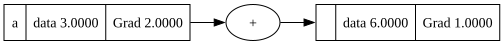

In [17]:
a = Value(3.0, label='a')

b = a+a # fixing bug in the main nn code by using += to accumulate gradient over the propagation

b.backward()
draw_dot(b)

In [127]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] #generate random value n weights for n neurons w = [w1, w2, ... wn]
        self.b = Value(random.uniform(-1, 1)) # bias has a random value

    def __call__(self, x):
        # w * x + b
        act = self.b
        for wi, xi in zip(self.w, x):
            act = act + wi * xi
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b] #concat the weight + bias list

class Layer:
    def __init__(self, nin, nout): #using a single neuron (nout)
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] #call Neuron.__call__(x)
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps) # add the neuron parameters into the params list
        return params

class MLP: # Multi-layer perceptron

    def __init__(self, nin, nouts): # using a list of neurons to create the layer (nouts)
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self): # to save all the weights and biases that can get adjusted
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps) # add the neuron parameters into the params list
        return params

In [45]:
x = [2.0, 3.0, -1.0] # inputs into the nn
n = MLP(3, [4, 4, 1]) # 3 inputs into two layers of 4 and 1 output
n(x)

Value(data=0.9677376210312635)

In [128]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] #desired targets
n = MLP(3, [4, 4, 1])
ypred = [n(x) for x in xs]
ypred

[Value(data=0.9649994006860799),
 Value(data=0.8043220922673306),
 Value(data=0.8297437336755795),
 Value(data=0.9755856500626664)]

In [125]:
ypred = [n(x) for x in xs]
loss = sum(((yout-ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

Value(data=9.033418292237227e-20)

In [104]:
ypred = [n(x) for x in xs]
loss = sum(((yout-ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

#ys    = [1.0, -1.0, 1.0] # target
#ypred = [0.8, -0.5, 0.3] # model predictions

#zip(ys, ypred) pairs elements together
#(1.0, 0.8)
#(-1.0, -0.5)
#(1.0, 0.3)

#each loop gets 
#ygt -> ground truth
#yout -> prediction

#Example:
#0.8 - 1.0 = -0.2

#(-0.2)**2 = 0.04 to remove negatives

#repeat and build a list [0.04, 0.25, 0.49]

#loss = (ypred - ys)**2 -> MSE without the mean


Value(data=0.005265385909574115)

In [ ]:
loss.backward() # use loss backward

In [69]:
n.layers[0].neurons[0].w[0].grad # grad of the first neuron of the first layer


0.21299777219991345

In [54]:
n.layers[0].neurons[0].w[0].data # value of the first neuron of the first layer

-0.25484275857438354

In [ ]:
# Entire process on a single cell

for k in range(10):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout-ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
    loss

    #backward pass
    for p in n.parameters():
        p.grad = 0.0 # set gradient to 0 to avoid accumulation of gradients when doing the backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.01 * p.grad
    
    print(k, loss.data)

0 0.0005478273013192074
1 0.000547652985266789
2 0.0005474787795054955
3 0.0005473046839308522
4 0.000547130698438509
5 0.0005469568229242465
6 0.0005467830572839763
7 0.0005466094014137516
8 0.000546435855209751
9 0.0005462624185682676
10 0.0005460890913857395
11 0.0005459158735587523
12 0.0005457427649839871
13 0.0005455697655582793
14 0.0005453968751785797
15 0.0005452240937419919
16 0.000545051421145714
17 0.0005448788572871021
18 0.000544706402063642
19 0.0005445340553729137
20 0.0005443618171126665
21 0.0005441896871807508
22 0.0005440176654751685
23 0.0005438457518940199
24 0.0005436739463355601
25 0.0005435022486981558
26 0.000543330658880319
27 0.0005431591767806666
28 0.000542987802297954
29 0.0005428165353310549
30 0.0005426453757789898
31 0.000542474323540878
32 0.0005423033785159861
33 0.0005421325406036984
34 0.000541961809703535
35 0.00054179118571512
36 0.0005416206685382142
37 0.0005414502580727208
38 0.0005412799542186394
39 0.00054110975687611
40 0.000540939665945389

In [124]:
ypred

[Value(data=0.9999999997961465),
 Value(data=-0.9999999999224567),
 Value(data=-0.9999999999504919),
 Value(data=0.9999999997992167)]

In [121]:
n.parameters() # set of weights and biases that make the network predict the parameters

[Value(data=1.566179632028555),
 Value(data=3.064905666844981),
 Value(data=-5.032011250039088),
 Value(data=0.2558896948866005),
 Value(data=-0.8442518570522328),
 Value(data=-0.6807814272909113),
 Value(data=0.45497352554440096),
 Value(data=-0.35173185059937534),
 Value(data=-2.1497908548213815),
 Value(data=-3.3481906720482497),
 Value(data=6.89873697398241),
 Value(data=-0.3232020967380613),
 Value(data=2.96960067730501),
 Value(data=-3.025150134468369),
 Value(data=1.217642104328214),
 Value(data=-0.2924581355502887),
 Value(data=0.8305230799403116),
 Value(data=0.40314601048129384),
 Value(data=-2.497561743275554),
 Value(data=0.35359546376556006),
 Value(data=-0.7948329905712358),
 Value(data=1.9297198220429463),
 Value(data=2.3691971162677095),
 Value(data=2.2048472547038425),
 Value(data=1.7841934800704016),
 Value(data=-3.5163284535017767),
 Value(data=-2.4618344997322263),
 Value(data=-0.4543632242553148),
 Value(data=2.7235388382130274),
 Value(data=-0.4451604732069865),
 

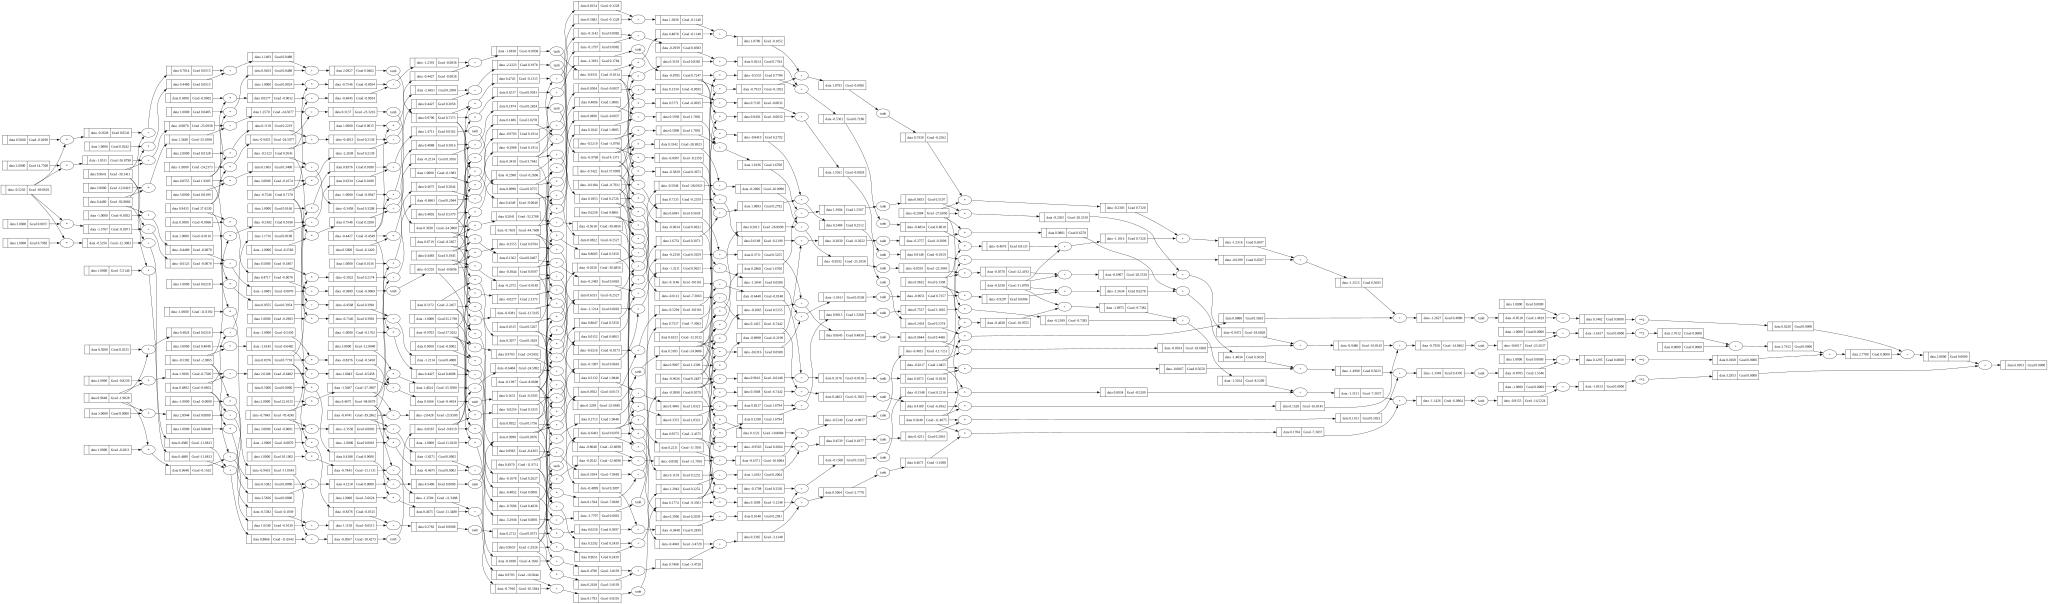

In [30]:
draw_dot(loss)